In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_auc_score,roc_curve

from xgboost import XGBClassifier,XGBRFClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.linear_model import LogisticRegression,RidgeClassifier,SGDClassifier
from sklearn.tree import DecisionTreeClassifier,ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier , BaggingClassifier , AdaBoostClassifier , GradientBoostingClassifier , HistGradientBoostingClassifier , ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier , RadiusNeighborsClassifier
from sklearn.svm import SVC,NuSVC,LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier

seed=1

In [ ]:
df=pd.read_csv("/content/train.csv")
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [ ]:
df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [ ]:
df[['gender', 'marital_status','education_level', 'employment_status', 'loan_purpose','grade_subgrade']]=df[['gender', 'marital_status','education_level', 'employment_status', 'loan_purpose','grade_subgrade']].astype('category')
df['loan_paid_back']=df['loan_paid_back'].astype(bool)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(['id','loan_paid_back'],axis=1),df['loan_paid_back'],test_size=0.2,random_state=seed,stratify=df['loan_paid_back'])


In [ ]:
cv_strat=StratifiedKFold(n_splits=5,shuffle=True,random_state=seed)

In [ ]:
model_config={
    "Dummy":{
        'model':DummyClassifier(strategy='most_frequent'),
        'params':{}
    },

    'LR':{
        'model':LogisticRegression(max_iter=2000,random_state=seed),
        'params':[
            {
                'c__solver':['saga','liblinear'],
                'c__penalty':['l1','l2'],
                'c__C':[0.1,1,10]
            },
            {
                'c__solver':['saga'],
                'c__penalty':['elasticnet'],
                'c__l1_ratio':[0.25,0.5,0.75],
                'c__C':[0.1,1,10]
            },
            {
                'c__solver':['lbfgs','newton-cg'],
                'c__penalty':['l2'],
                'c__C':[0.1,1,10]
            }

        ]
    },

    #skipping hinge loss due to no predict_proba
    'SGD':{
      'model':SGDClassifier(random_state=seed,n_jobs=-1,early_stopping=True),
      'params':[
          {
              'c__loss':['log_loss','modified_huber'],
              'c__penalty':['l1','l2'],
              'c__alpha':[0.000001,0.00001,0.0001,0.001,0.01,0.1,1],
              'c__learning_rate':['optimal'],
              'c__class_weight':['balanced',None]
          },
          {
              'c__loss':['log_loss','modified_huber'],
              'c__penalty':['elasticnet'],
              'c__l1_ratio':[0.25,0.5,0.75],
              'c__alpha':[0.000001,0.00001,0.0001,0.001,0.01,0.1,1],
              'c__learning_rate':['optimal'],
              'c__class_weight':['balanced',None]
          },
          {
              'c__loss':['log_loss','modified_huber'],
              'c__penalty':['l1','l2'],
              'c__alpha':[0.000001,0.00001,0.0001,0.001,0.01,0.1,1],
              'c__learning_rate':['adaptive'],
              'c__eta0':[0.001,0.01,0.1,1],
              'c__class_weight':['balanced',None]

        }
    ]
    },

    'Ridge':{
        'model':RidgeClassifier(random_state=seed),
        'params':{
            'c__class_weight':['balanced',None],
            "c__alpha":[0.0001,0.001,0.01,0.1,1,10,100],
            'c__solver':['auto', 'cholesky', 'sag', 'lsqr','svd']

        }
    },

    'DT':{
        'model':DecisionTreeClassifier(random_state=seed),
        'params':{
            'c__max_depth':[5,10,15,20,None],
            'c__class_weight':['balanced',None],
            'c__criterion':["gini", "entropy", "log_loss"],
            'c__max_features':[None,'sqrt','log2'],
            'c__min_samples_leaf':[1,10,50,100,200]
        }
    },

    'RF':{
        'model':RandomForestClassifier(random_state=seed,n_jobs=-1,),
        'params':[
            {
                'c__n_estimators': [10,50,100,200],
                'c__max_depth': [10,15,20, None],
                'c__min_samples_leaf': [1, 5,100,200],
                'c__max_features': ['sqrt', 'log2'],
                'c__bootstrap': [True],
                'c__max_samples': [None, 0.5, 0.7],
                'c__criterion': ['gini', 'entropy'],
                'c__class_weight': ['balanced','balanced_subsample', None]
            },
            {
                'c__n_estimators': [10,50,100],
                'c__max_depth': [10,15,20],
                'c__min_samples_leaf': [1, 5,100,200],
                'c__max_features': ['sqrt'],
                'c__bootstrap': [False],
                'c__criterion': ['gini'],
                'c__class_weight': ['balanced']
            }
        ]

    },

    'ET':{
        'model': ExtraTreesClassifier(random_state=seed, n_jobs=-1),
        'params': {
            'c__n_estimators': [100, 200, 300],
            'c__max_depth': [10, 20, 30, None],
            'c__min_samples_leaf': [1, 5, 10,50,100,200],
            'c__max_features': [0.1,'sqrt', 'log2',0.5, None],
            'c__criterion': ['gini', 'entropy'],
            'c__bootstrap': [True, False],
            'c__class_weight': ['balanced', None]
        }

    },

    'ABC':{
        'model': AdaBoostClassifier(random_state=seed,),
        'params': {
            'c__n_estimators': [50, 100, 200,500,1000],
            'c__learning_rate': [0.0001,0.001,0.01, 0.1, 1.0, 10.0,100],
        }

    },

    'GBC':{
        'model': GradientBoostingClassifier(random_state=seed),
        'params': {
            'c__n_estimators': [100, 200, 300],
            'c__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'c__max_depth': [3, 5, 8],
            'c__subsample': [0.8, 1.0],
            'c__max_features': ['sqrt', None]
        }

    },

    'HGBC':{
        'model': HistGradientBoostingClassifier(random_state=seed, early_stopping=True),
        'params': {
            'c__max_iter': [100, 200, 500],
            'c__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'c__max_depth': [None, 10, 20],
            'c__max_leaf_nodes': [31, 63, 127],
            'c__l2_regularization': [0.0, 1.0, 10.0]
        }

    },

    'XGB': {
        'model': XGBClassifier(random_state=seed, n_jobs=-1, eval_metric='logloss'),
        'params': {
            'c__n_estimators': [100, 300, 500],
            'c__learning_rate': [0.01, 0.05, 0.1],
            'c__max_depth': [3, 6, 9],
            'c__min_child_weight': [1, 5],
            'c__gamma': [0, 0.1, 0.5],
            'c__subsample': [0.8, 1.0],
            'c__colsample_bytree': [0.8, 1.0]
        }
    },

    'LGBM': {
        'model': LGBMClassifier(random_state=seed, n_jobs=-1, verbose=-1),
        'params': {
            'c__n_estimators': [100, 300, 500],
            'c__learning_rate': [0.01, 0.05, 0.1],
            'c__num_leaves': [31, 63, 127],
            'c__max_depth': [-1, 10, 20],
            'c__reg_alpha': [0.0, 0.1, 1.0],
            'c__reg_lambda': [0.0, 0.1, 1.0]
        }
    },

    'CatBoost': {
        'model': CatBoostClassifier(random_state=seed, verbose=0, thread_count=-1),
        'params': {
            'c__iterations': [200, 500, 800],
            'c__learning_rate': [0.01, 0.05, 0.1],
            'c__depth': [4, 6, 8, 10],
            'c__l2_leaf_reg': [1, 3, 5, 10],
            'c__border_count': [32, 64, 128]
        }
    },

    'GaussianNB': {
        'model': GaussianNB(),
        'params': {
            'c__var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    },

    'KNN': {
        'model': KNeighborsClassifier(n_jobs=-1),
        'params': {
            'c__n_neighbors': [5, 15, 30, 50],
            'c__weights': ['uniform', 'distance'],
            'c__metric': ['euclidean', 'manhattan']
        }
    },

    'MLP': {
        'model': MLPClassifier(random_state=seed, max_iter=500),
        'params': {
            'c__hidden_layer_sizes': [(50,), (100,), (50, 50)],
            'c__activation': ['relu', 'tanh'],
            'c__alpha': [0.0001, 0.01],
            'c__learning_rate_init': [0.001, 0.01]
        }
    }


}

In [ ]:
def run_benchmark(X,y,config,cv_strategy,verbose=1):

  result=[]

  num_pipeline=Pipeline([
      ('imputer',SimpleImputer(strategy='median')),
      ('scaler',StandardScaler())
  ])
  cat_pipeline=Pipeline([
      ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
      ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
  ])

  preprocessor=ColumnTransformer([
      ('num',num_pipeline, make_column_selector(dtype_include='number')),
      ('cat',cat_pipeline, make_column_selector(dtype_include=['object','category']))
  ])


  print(f"starting benchmark with {len(config)} model...")

  for model_name,settings in config.items():
    print(f"training {model_name}...")

    try:

      pipe=Pipeline([
          ("prep",preprocessor),
          ('c',settings['model'])
      ])


      search=RandomizedSearchCV(
          estimator=pipe,
          param_distributions=settings['params'],
          n_iter=50,
          scoring="roc_auc",
          cv=cv_strategy,
          n_jobs=-1,
          random_state=seed,
          verbose=verbose
          )

      search.fit(X,y)

      cv_results=pd.DataFrame(search.cv_results_)
      top10=cv_results.sort_values(by='rank_test_score').head(10)

      for i, row in top10.iterrows():
          record = {
              'Model': model_name,
              'Rank': row['rank_test_score'],
              'AUC': row['mean_test_score'],
              'Params': str(row['params'])
          }


          pd.DataFrame([record]).to_csv('benchmark_log_detailed.csv', mode='a', header=False, index=False)

      bot10=cv_results.sort_values(by='rank_test_score').tail(10)

      for i,row in bot10.iterrows():
        record={
            'Model': model_name,
            'Rank' : row['rank_test_score'],
            'AUC' : row['mean_test_score'],
            'Params': str(row['Params'])
        }

        pd.DataFrame([record]).to_csv('benchmark_log_detailed.csv',mode='a', header=False,index=False)

      best_score=search.best_score_
      print(f'{model_name} best auc: {best_score: .4f}')

      result.append({
          'model': model_name,
          'best AUC':best_score,
          'best Params':search.best_params_,
          'Full Estimator':search.best_estimator_
      })

      pd.DataFrame([{
          'model': model_name,
          'best AUC':best_score,
          'best Params':search.best_params_
      }]).to_csv('benchmark_log.csv',mode='a',header=False,index=False)

    except Exception as e:
      print(f'error trraining {model_name}: {str(e)}')
      print('skipping to next model')
      continue

  print('benchmark completed')
  return pd.DataFrame(result).sort_values(by='best AUC',ascending=False)

In [ ]:
#wrong way to create tuning set, since weights parameter doesnt work the same way as stratify
'''X_tune=X_train.sample(100000,weights=y_train,random_state=seed,axis=0)
y_tune=y_train[X_tune.index]
print(y_tune.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))'''

'X_tune=X_train.sample(100000,weights=y_train,random_state=seed,axis=0)\ny_tune=y_train[X_tune.index]\nprint(y_tune.value_counts(normalize=True))\nprint(y_train.value_counts(normalize=True))'

In [ ]:
#since the benchmarking took too long on full train, creating a tune set then checking for difference.
X_tune,_,y_tune,_=train_test_split(X_train,y_train,train_size=100000,random_state=seed,stratify=y_train)

In [ ]:
X_tune

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
365988,29370.88,0.264,682,12994.56,11.26,Female,Single,Master's,Retired,Debt consolidation,C1
571824,50366.68,0.167,715,12185.65,11.96,Female,Married,Master's,Employed,Debt consolidation,C2
454033,24512.80,0.132,689,13832.26,7.34,Male,Married,High School,Employed,Debt consolidation,C4
255344,67734.68,0.179,657,20360.60,12.26,Female,Married,Master's,Employed,Vacation,D4
495429,46361.04,0.191,615,28302.98,14.11,Female,Married,High School,Employed,Debt consolidation,D5
...,...,...,...,...,...,...,...,...,...,...,...
367457,65710.33,0.178,735,28303.81,12.98,Male,Married,Bachelor's,Retired,Other,C2
293878,70949.72,0.093,736,13609.13,9.15,Male,Married,Bachelor's,Employed,Debt consolidation,C3
183284,39462.47,0.166,662,27443.65,12.16,Male,Married,Bachelor's,Employed,Vacation,D5
329215,54826.31,0.133,733,17586.28,12.84,Male,Married,Bachelor's,Employed,Other,C5


In [ ]:
y_tune.value_counts(normalize=True)

,proportion
loan_paid_back,
True,0.79882
False,0.20118


In [ ]:
X_train.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,475195.000000,475195.000000,475195.000000,475195.000000,475195.000000
mean,48213.906440,0.120664,680.923829,15020.069721,12.358917
std,26700.948834,0.068529,55.438932,6932.635825,2.008864
min,6002.430000,0.011000,395.000000,500.090000,3.200000
25%,27950.380000,0.072000,646.000000,10275.010000,10.990000
50%,46607.700000,0.096000,682.000000,15000.800000,12.370000
75%,60971.320000,0.156000,719.000000,18875.375000,13.680000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000


In [ ]:
X_tune.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,48283.539160,0.120536,680.750930,14983.535719,12.363537
std,26652.075285,0.068535,55.445373,6922.651475,2.008013
min,6100.320000,0.011000,395.000000,500.370000,3.790000
25%,28004.370000,0.072000,646.000000,10248.100000,11.000000
50%,46656.160000,0.096000,682.000000,14972.150000,12.390000
75%,60971.552500,0.156000,719.000000,18759.290000,13.680000
max,371058.530000,0.627000,849.000000,48954.700000,20.990000


In [ ]:
'''from scipy.stats import ks_2samp

print("--- Statistical Distribution Check ---")
for col in ['annual_income', 'credit_score', 'loan_amount','debt_to_income_ratio','interest_rate']:
    stat, p_value = ks_2samp(X_train[col], X_tune[col])

    print(f"Column: {col}")
    print(f"   KS Statistic: {stat:.4f}")
    print(f"   P-Value: {p_value:.4f}")
    if p_value > 0.05:
        print("   ✅ Distributions are statistically IDENTICAL.")
    else:
        print("   ⚠️ Distributions might differ slightly (Check visually).")
    print("-" * 30)'''

--- Statistical Distribution Check ---
Column: annual_income
   KS Statistic: 0.0025
   P-Value: 0.7006
   ✅ Distributions are statistically IDENTICAL.
------------------------------
Column: credit_score
   KS Statistic: 0.0018
   P-Value: 0.9419
   ✅ Distributions are statistically IDENTICAL.
------------------------------
Column: loan_amount
   KS Statistic: 0.0033
   P-Value: 0.3206
   ✅ Distributions are statistically IDENTICAL.
------------------------------
Column: debt_to_income_ratio
   KS Statistic: 0.0019
   P-Value: 0.9236
   ✅ Distributions are statistically IDENTICAL.
------------------------------
Column: interest_rate
   KS Statistic: 0.0021
   P-Value: 0.8423
   ✅ Distributions are statistically IDENTICAL.
------------------------------


📊 Comparing Train (475195 rows) vs Tune (100000 rows)

--- 🔢 Checking 5 Numerical Columns ---


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


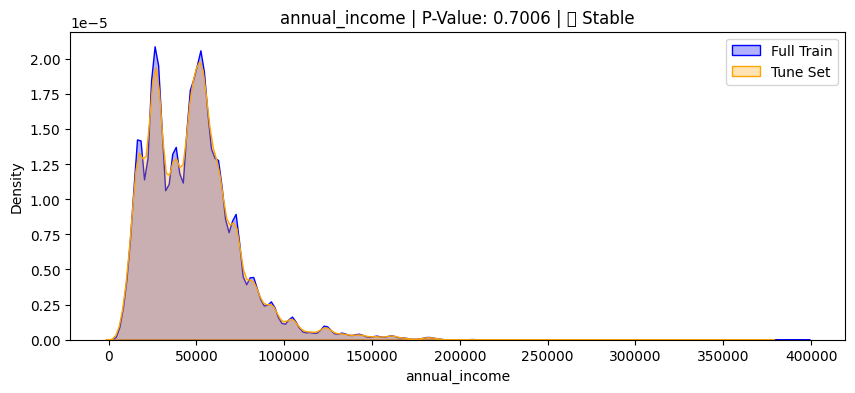

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


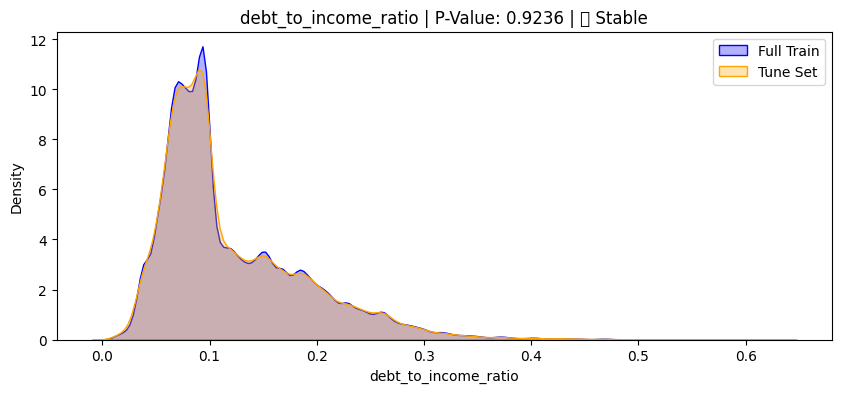

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


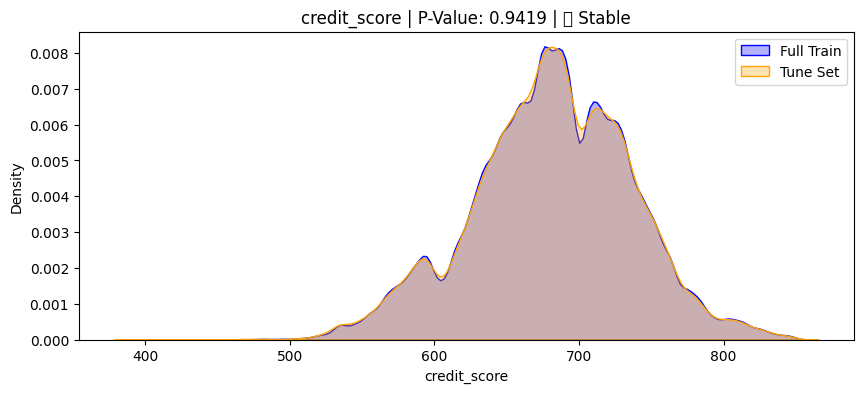

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


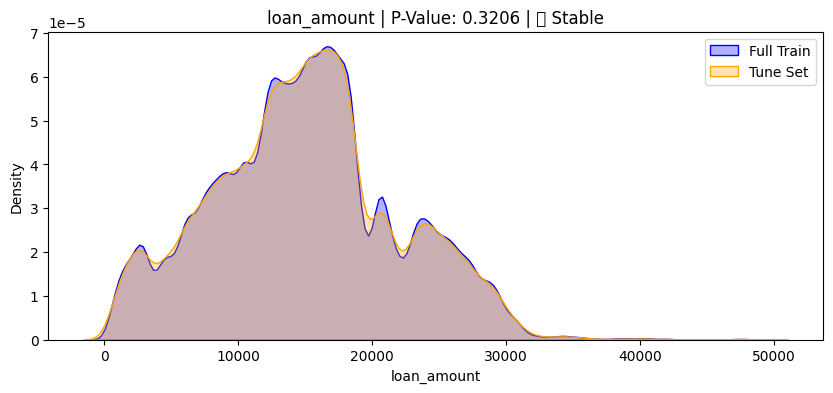

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


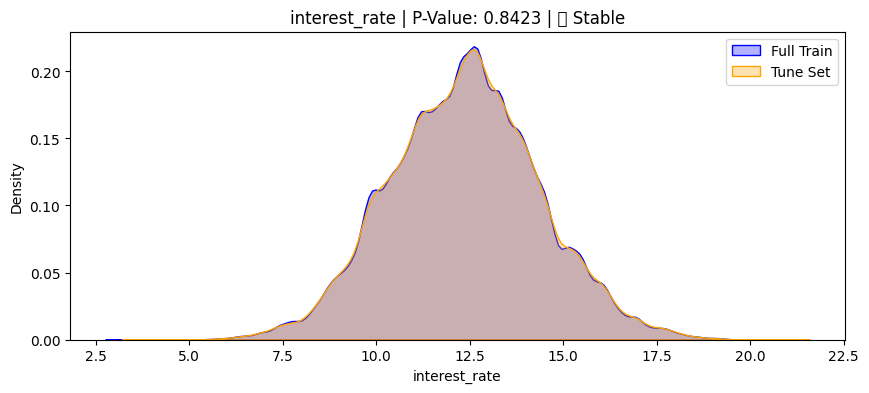


--- 🔠 Checking 6 Categorical Columns ---


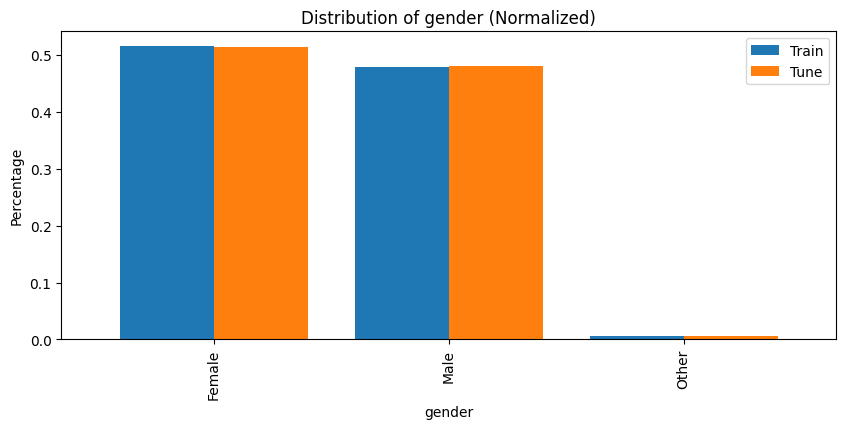

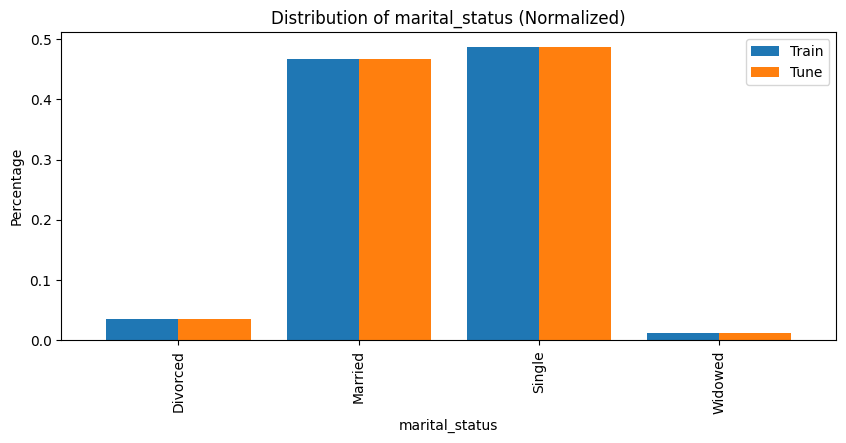

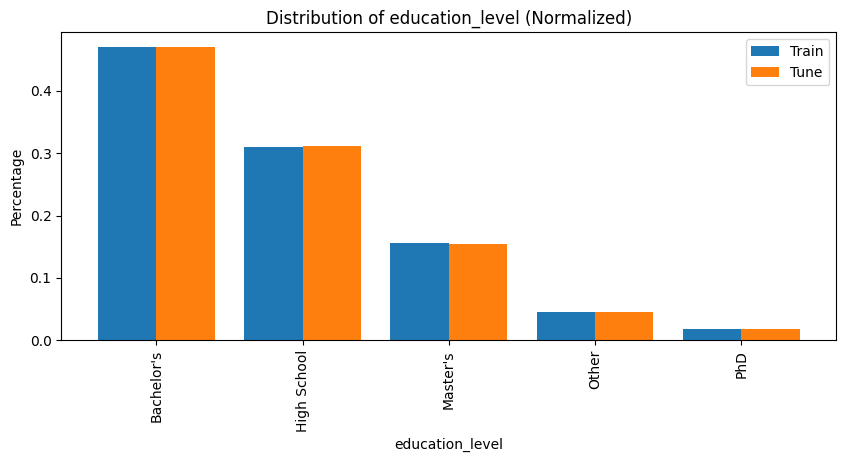

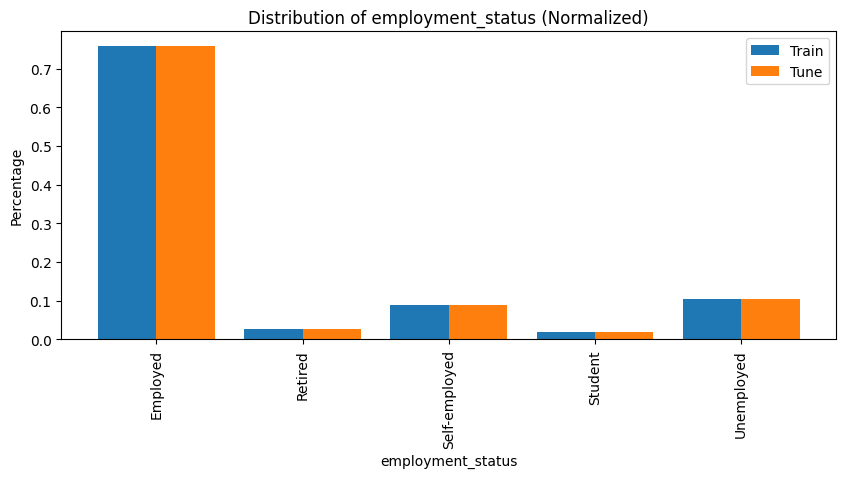

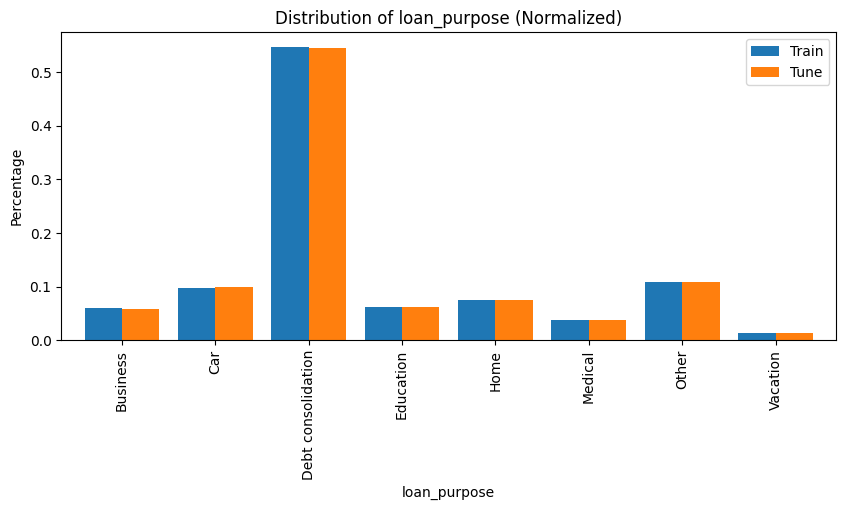

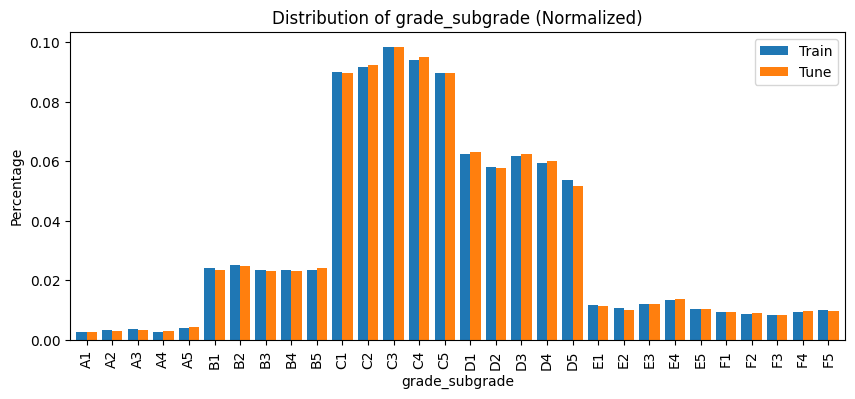

In [ ]:
'''import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency

def compare_datasets(train_df, tune_df):
    print(f"📊 Comparing Train ({len(train_df)} rows) vs Tune ({len(tune_df)} rows)\n")

    # 1. Identify Column Types
    num_cols = train_df.select_dtypes(include=['number']).columns
    cat_cols = train_df.select_dtypes(exclude=['number']).columns

    # --- PART A: NUMERICAL COLUMNS ---
    print(f"--- 🔢 Checking {len(num_cols)} Numerical Columns ---")
    for col in num_cols:
        # Statistical Test (KS Test)
        stat, p_value = ks_2samp(train_df[col], tune_df[col])
        drift_status = "🔴 DRIFT DETECTED" if p_value < 0.05 else "✅ Stable"

        # Visualization (KDE Plot)
        plt.figure(figsize=(10, 4))
        sns.kdeplot(train_df[col], label='Full Train', color='blue', fill=True, alpha=0.3)
        sns.kdeplot(tune_df[col], label='Tune Set', color='orange', fill=True, alpha=0.3)
        plt.title(f"{col} | P-Value: {p_value:.4f} | {drift_status}")
        plt.legend()
        plt.show()

    # --- PART B: CATEGORICAL COLUMNS ---
    print(f"\n--- 🔠 Checking {len(cat_cols)} Categorical Columns ---")
    for col in cat_cols:
        # Skip columns with too many categories (like 'id' if it snuck in)
        if train_df[col].nunique() > 50:
            print(f"Skipping {col} (Too many categories: {train_df[col].nunique()})")
            continue

        # Create Frequency Table
        count_train = train_df[col].value_counts(normalize=True).sort_index()
        count_tune = tune_df[col].value_counts(normalize=True).sort_index()

        # Align and Plot
        df_compare = pd.DataFrame({'Train': count_train, 'Tune': count_tune}).fillna(0)

        # Visual Check (Bar Plot)
        df_compare.plot(kind='bar', figsize=(10, 4), width=0.8)
        plt.title(f"Distribution of {col} (Normalized)")
        plt.ylabel("Percentage")
        plt.show()

# Run it!
compare_datasets(X_train, X_tune)'''

In [ ]:
run_benchmark(X_tune,y_tune,model_config,cv_strat)

starting benchmark with 5 model...
training Dummy...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=50. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Dummy best auc:  0.5000
training LR...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 27 is smaller than n_iter=50. Running 27 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LR best auc:  0.9092
training SGD...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
SGD best auc:  0.9094
training Ridge...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Ridge best auc:  0.9089
training DT...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
DT best auc:  0.9084
benchmark completed


,model,best AUC,best Params,Full Estimator
2,SGD,0.909399,"{'c__penalty': 'l1', 'c__loss': 'log_loss', 'c...","(ColumnTransformer(transformers=[('num',\n ..."
1,LR,0.909248,"{'c__solver': 'liblinear', 'c__penalty': 'l1',...","(ColumnTransformer(transformers=[('num',\n ..."
3,Ridge,0.908888,"{'c__solver': 'svd', 'c__class_weight': 'balan...","(ColumnTransformer(transformers=[('num',\n ..."
4,DT,0.908418,"{'c__min_samples_leaf': 100, 'c__max_features'...","(ColumnTransformer(transformers=[('num',\n ..."
0,Dummy,0.500000,{},"(ColumnTransformer(transformers=[('num',\n ..."
